In [28]:
def heapify(A, n, i):
    # Assume root is largest
    largest = i
    left = 2 * i + 1 # left child index
    right = 2 * i + 2 # right child index
    
    # check if left child exists and is > root
    if left < n and A[left] > A[largest]:
        largest = left
    # check if right child exists and is > largest
    if right < n and A[right] > A[largest]:
        largest = right
    # if largest is not the root, swap and heapify subtree
    if largest != i:
        A[i], A[largest] = A[largest], A[i]
        heapify(A, n, largest)

In [29]:
def build_heap(A, n):
    
    # build max heap from array
    for i in range(n // 2 - 1, -1, -1):
        heapify(A, n, i)

In [30]:
def heap_sort(A):
    n = len(A)
    
    if n <= 1:
        return

    build_heap(A, n)
    
    n -= 1
    # move max to end, re-heapify
    while n > 0:
        A[0], A[n] = A[n], A[0]
        heapify(A, n, 0)
        n -= 1

In [31]:
def merge(A, left, mid, right):
    # n1 and n2 are the sizes of subarrays to merge
    n1 = mid - left + 1
    n2 = right - mid
    
    # temp left and right arrays
    L = [0] * n1
    R = [0] * n2
    
    # copy data to temps
    for i in range(n1):
        L[i] = A[left + i]
    for j in range(n2):
        R[j] = A[mid + 1 + j]
        
    i = 0 # L index
    j= 0 # R index
    k = left # merged array index
    
    # merge by comparing L and R
    while i < n1 and j < n2:
        if L[i] <= R[j]:
            A[k] = L[i]
            i += 1
        else:
            A[k] = R[j]
            j += 1
        k += 1
    
    # copy remaining elements from L
    while i < n1:
        A[k] = L[i]
        i += 1
        k += 1
    
    # copy remaining elements from R    
    while j < n2:
        A[k] = R[j]
        j += 1
        k += 1

In [32]:
def merge_sort(A, left, right):
    if left < right:
        mid = (left + right) // 2 # find midpoint
        merge_sort(A, left, mid) # recurse on left half
        merge_sort(A, mid + 1, right) # recurse of right half
        if A[mid] > A[mid + 1]: # early exit check
            merge(A, left, mid, right)

In [33]:
import time
import random

merge_times = []
heap_times = []

sizes = [500, 2000, 4000, 6000, 8000, 10000] # input sizes
trials = 10 # trials per input size

for n in sizes:
    merge_trials = []
    heap_trials = []
    
    for _ in range(trials):
        # random array of n unique elements
        A = random.sample(range(n * 10), n)
        
        # time merge sort execution
        A_merge = A[:]
        start = time.perf_counter()
        merge_sort(A_merge, 0, len(A_merge) - 1)
        merge_trials.append(time.perf_counter() - start)
        
        # time heap sort execution
        A_heap = A[:]
        start = time.perf_counter()
        heap_sort(A_heap)
        heap_trials.append(time.perf_counter() - start)
    
    # store average time across all trials
    merge_times.append(sum(merge_trials) / trials)
    heap_times.append(sum(heap_trials) / trials)

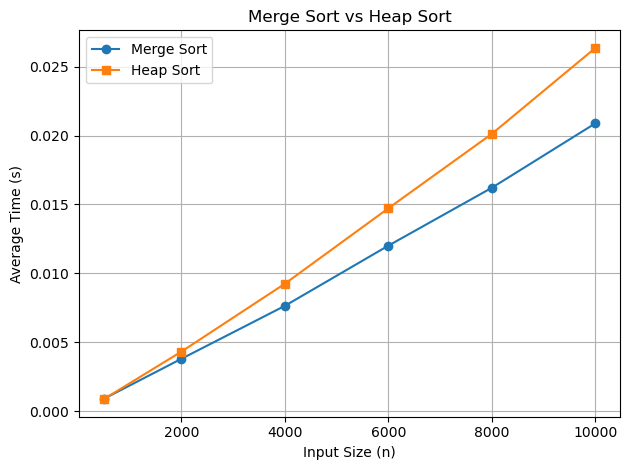

In [34]:
# plot times against input sizes
import matplotlib.pyplot as plt

plt.plot(sizes, merge_times, marker='o', label = "Merge Sort")
plt.plot(sizes, heap_times, marker='s', label="Heap Sort")
plt.xlabel("Input Size (n)")
plt.ylabel("Average Time (s)")
plt.title("Merge Sort vs Heap Sort")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [35]:
# source: https://cs.stackexchange.com/questions/108968/can-this-double-pop-heapsort-variation-speed-up-sorting-on-average
def dp_heap_sort(A):
    n = len(A)
    
    if n <=1:
        return
    
    build_heap(A, n)
        
    n -= 1
    while n > 2:
        # place max at sorted end of array
        A[0], A[n] = A[n], A[0]
        n -= 1
        
        # 2nd largest is larger child of root
        # place at next sorted position
        if A[1] >= A[2]:
            A[1], A[n] = A[n], A[1]
            heapify(A, n, 1) # re-heapify below left child
        else:
            A[2], A[n] = A[n], A[2]
            heapify(A, n, 2) # re-heapify below right child

        heapify(A, n, 0) # restore max heap property
        n -= 1
        
    # regular heap sort for last 3 elements
    while n > 0:
        A[0], A[n] = A[n], A[0]
        heapify(A, n, 0)
        n -= 1

In [36]:
# test code to make sure doublePop works the same as heapSort
test_arr = random.sample(range(1000), 20)
expected = sorted(test_arr)
A_merge = test_arr[:]
A_heap = test_arr[:]
arr_dpop = test_arr[:]

merge_sort(A_merge, 0, len(A_merge) - 1)
heap_sort(A_heap)
dp_heap_sort(arr_dpop)

print(f"Input:    {test_arr}")
print(f"Expected: {expected}")
print(f"Merge Sort:       {A_merge}  {'PASS' if A_merge == expected else 'FAIL'}")
print(f"Heap Sort:        {A_heap}  {'PASS' if A_heap == expected else 'FAIL'}")
print(f"Double Pop Sort:  {arr_dpop}  {'PASS' if arr_dpop == expected else 'FAIL'}")

Input:    [430, 738, 174, 603, 155, 570, 396, 263, 425, 458, 54, 393, 504, 187, 547, 437, 559, 311, 375, 654]
Expected: [54, 155, 174, 187, 263, 311, 375, 393, 396, 425, 430, 437, 458, 504, 547, 559, 570, 603, 654, 738]
Merge Sort:       [54, 155, 174, 187, 263, 311, 375, 393, 396, 425, 430, 437, 458, 504, 547, 559, 570, 603, 654, 738]  PASS
Heap Sort:        [54, 155, 174, 187, 263, 311, 375, 393, 396, 425, 430, 437, 458, 504, 547, 559, 570, 603, 654, 738]  PASS
Double Pop Sort:  [54, 155, 174, 187, 263, 311, 375, 393, 396, 425, 430, 437, 458, 504, 547, 559, 570, 603, 654, 738]  PASS


In [37]:
merge_times = []
heap_times = []
dpop_times = []

sizes = [500, 2000, 4000, 6000, 8000, 10000] # input sizes
trials = 10 # trials per input size

for n in sizes:
    merge_trials = []
    heap_trials = []
    dpop_trials = []
    
    for _ in range(trials):
        # random array of n unique elements
        A = random.sample(range(n * 10), n)
        
        # time merge sort execution
        A_merge = A[:]
        start = time.perf_counter()
        merge_sort(A_merge, 0, len(A_merge) - 1)
        merge_trials.append(time.perf_counter() - start)
        
        # time heap sort execution
        A_heap = A[:]
        start = time.perf_counter()
        heap_sort(A_heap)
        heap_trials.append(time.perf_counter() - start)
        
        # time dpop sort execution
        arr_dpop = A[:]
        start = time.perf_counter()
        dp_heap_sort(arr_dpop)
        dpop_trials.append(time.perf_counter() - start)
    
    # store average time across all trials
    merge_times.append(sum(merge_trials) / trials)
    heap_times.append(sum(heap_trials) / trials)
    dpop_times.append(sum(dpop_trials) / trials)

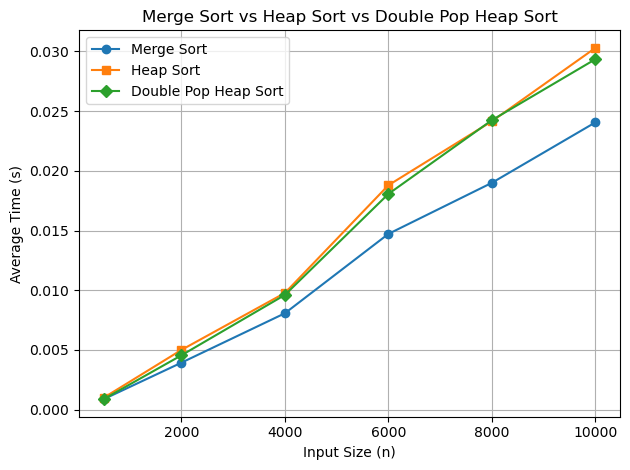

In [38]:
plt.plot(sizes, merge_times, marker='o', label = "Merge Sort")
plt.plot(sizes, heap_times, marker='s', label="Heap Sort")
plt.plot(sizes, dpop_times, marker='D', label="Double Pop Heap Sort")
plt.xlabel("Input Size (n)")
plt.ylabel("Average Time (s)")
plt.title("Merge Sort vs Heap Sort vs Double Pop Heap Sort")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [39]:
merge_times = []
heap_times = []
dpop_times = []

sizes = [500, 2000, 4000, 6000, 8000, 10000, 100000, 500000] # input sizes
trials = 10 # trials per input size

for n in sizes:
    merge_trials = []
    heap_trials = []
    dpop_trials = []
    
    for _ in range(trials):
        # random array of n unique elements
        A = random.sample(range(n * 10), n)
        
        # time merge sort execution
        A_merge = A[:]
        start = time.perf_counter()
        merge_sort(A_merge, 0, len(A_merge) - 1)
        merge_trials.append(time.perf_counter() - start)
        
        # time heap sort execution
        A_heap = A[:]
        start = time.perf_counter()
        heap_sort(A_heap)
        heap_trials.append(time.perf_counter() - start)
        
        # time dpop sort execution
        arr_dpop = A[:]
        start = time.perf_counter()
        dp_heap_sort(arr_dpop)
        dpop_trials.append(time.perf_counter() - start)
    
    # store average time across all trials
    merge_times.append(sum(merge_trials) / trials)
    heap_times.append(sum(heap_trials) / trials)
    dpop_times.append(sum(dpop_trials) / trials)

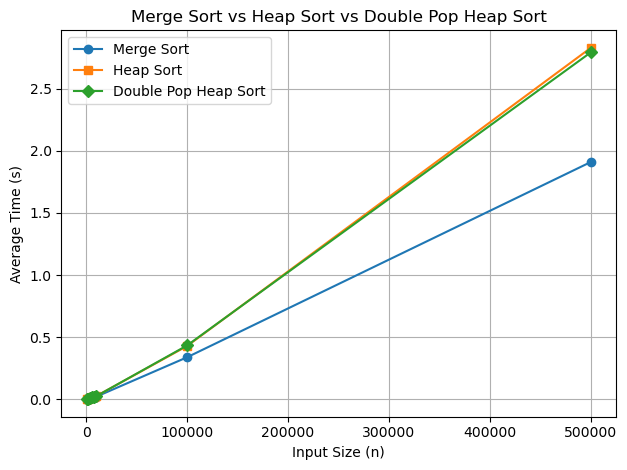

In [40]:
plt.plot(sizes, merge_times, marker='o', label = "Merge Sort")
plt.plot(sizes, heap_times, marker='s', label="Heap Sort")
plt.plot(sizes, dpop_times, marker='D', label="Double Pop Heap Sort")
plt.xlabel("Input Size (n)")
plt.ylabel("Average Time (s)")
plt.title("Merge Sort vs Heap Sort vs Double Pop Heap Sort")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()